# Section 9 : APOE interaction
Here we test if the identified QTL variants have significant interaction with APOE4 i) in IPSC data, ii) in ROSMAP postmortem data (bulk and celltype spe)

The steps are:
- get the variants genotype informations
- get the expression for the genes
- perform interaction analysis with APOE4*
For both TCW and Young-Pearse iPSC data.

*To limit multi-testing in the ROSMAP postmortem, we will test only the context and one SNPs per QTL/credible set of interest : the one that have been validated or suggestive previously or being a known context for this gene in litterature.  BIN1 have important effect in Microglia (based on this analysis) but also in [Excitatory Neurons](https://www.nature.com/articles/s41380-024-02502-y) . Let's then choose to focus on Mic and Exc, and bulk DLPFC. 

## IPSC data
### TCW data

In [1]:
source('../../codes/insilico_valid_utils.r',chdir=T)
gene_name='BIN1'
conts_of_int<-c('Mic','Exc','DLPFC')#put context of interests in IPSC data and ROSMAP ps data among= AC,Ast,DLPFC,Exc,Inh,Mic,Monocyte,OPC,Oli,PCC
tar_gene_info <- get_gene_info(gene_name = gene_name)
gene_id <- tar_gene_info$gene_info$region_id


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors



Attaching package: ‘data.table’




The following objects are masked from ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year




The following objects are masked from ‘package:dplyr’:

    between, first, last




The following object is masked from ‘package:purrr’:

    transpose





Attaching package: ‘cowplot’




The following object is masked from ‘package:lubridate’:

    stamp




In [2]:

variants_of_int <- read.table("variant_id.txt", stringsAsFactors = FALSE)

# if no coloc sets with AD, take the colocs sets with the bigger number of contexts linked
if(length(variants_of_int)==0){
    cb_res_table<-data.table(readRDS( paste0(gene_name, "_colocboost_res.rds")))
    cb_res_table[,n.coloc:=str_count(cset_id,'Y')]
    variants_of_int<-cb_res_table[n.coloc==max(n.coloc)]$max_abs_z_variant
}
variants_of_int

V1
<chr>
chr2:127135234:C:T


In [3]:
geno_tcw=GetGenoTCWiPSC(variants =variants_of_int)
head(geno_tcw)

1/1 SNPs found



Loading required package: parallel



1 ref SNPs found in the vcf (100% of the refs, 7.7% of the vcf)



renaming IDs for matching variants based on reference



1 SNPs matching alleles.



counting dose of alternative alleles



POS,#CHROM,ID,REF,ALT,QUAL,FILTER,INFO,FORMAT,maf,R2,rand_ind_id,genotype,genotype_info,region,gene_name,CHROM,flipped_allele,dose
<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<int>
127135234,chr2,chr2:127135234:C:T,C,T,.,.,AF=0.365323;MAF=0.365323;AVG_CS=0.9999;R2=0.999572;ER2=0.97855;TYPED;IMPUTED,GT:GP:DS:HDS,0.365323,0.999572,ID8,1|1,"1|1:0,0.011,0.989:1.989:0.989,1",chr2:123882048-130712494,BIN1,chr2,FALSE,2
127135234,chr2,chr2:127135234:C:T,C,T,.,.,AF=0.365323;MAF=0.365323;AVG_CS=0.9999;R2=0.999572;ER2=0.97855;TYPED;IMPUTED,GT:GP:DS:HDS,0.365323,0.999572,ID9,0|0,"0|0:1,0,0:0:0,0",chr2:123882048-130712494,BIN1,chr2,FALSE,0
127135234,chr2,chr2:127135234:C:T,C,T,.,.,AF=0.365323;MAF=0.365323;AVG_CS=0.9999;R2=0.999572;ER2=0.97855;TYPED;IMPUTED,GT:GP:DS:HDS,0.365323,0.999572,ID10,0|0,"0|0:1,0,0:0:0,0",chr2:123882048-130712494,BIN1,chr2,FALSE,0
127135234,chr2,chr2:127135234:C:T,C,T,.,.,AF=0.365323;MAF=0.365323;AVG_CS=0.9999;R2=0.999572;ER2=0.97855;TYPED;IMPUTED,GT:GP:DS:HDS,0.365323,0.999572,ID11,1|1,"1|1:0,0,1:2:1,1",chr2:123882048-130712494,BIN1,chr2,FALSE,2
127135234,chr2,chr2:127135234:C:T,C,T,.,.,AF=0.365323;MAF=0.365323;AVG_CS=0.9999;R2=0.999572;ER2=0.97855;TYPED;IMPUTED,GT:GP:DS:HDS,0.365323,0.999572,ID12,1|1,"1|1:0,0,1:2:1,1",chr2:123882048-130712494,BIN1,chr2,FALSE,2
127135234,chr2,chr2:127135234:C:T,C,T,.,.,AF=0.365323;MAF=0.365323;AVG_CS=0.9999;R2=0.999572;ER2=0.97855;TYPED;IMPUTED,GT:GP:DS:HDS,0.365323,0.999572,ID13,1|1,"1|1:0,0,1:2:1,1",chr2:123882048-130712494,BIN1,chr2,FALSE,2


In [4]:
expr_tcw<-GetExprTCWiPSC(gname=gene_name)
head(expr_tcw)

extracting residuals expression data for BIN1 (ENSG00000136717)



adding samples metadata



performing log2 normalization 



0 outlier found



sample_rand_id,gene_id,gene_name,expr,rand_ind_id,SEX,CellType,APOE,APOE4dose,batch,disease,RIN,ERC,GRSnoAPOE,proportion,norm_expr,is.outlier
<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<lgl>
A10_44,ENSG00000136717,BIN1,11702.563,ID10,M,Astrocyte,44,2,b1,2,10.0,1,0.00468,1,13.51454,FALSE
A11_44,ENSG00000136717,BIN1,8494.237,ID11,M,Astrocyte,44,2,b1,2,9.8,1,0.00772,1,13.05227,FALSE
A12_44,ENSG00000136717,BIN1,7060.854,ID12,F,Astrocyte,44,2,b1,2,10.0,2,0.01203,1,12.78563,FALSE
A13_44,ENSG00000136717,BIN1,13024.688,ID13,M,Astrocyte,44,2,b2,2,10.0,1,0.00652,1,13.66896,FALSE
A1_33,ENSG00000136717,BIN1,9311.595,ID1,F,Astrocyte,33,0,b2,1,10.0,1,0.01910,1,13.18481,FALSE
A2_33,ENSG00000136717,BIN1,7047.555,ID2,M,Astrocyte,33,0,b1,1,10.0,1,-0.00047,1,12.78291,FALSE


the function check if some outlier can be found based on the `boxplot.stats()$out`. These outliers should eventually be removed to ensure normal distribution

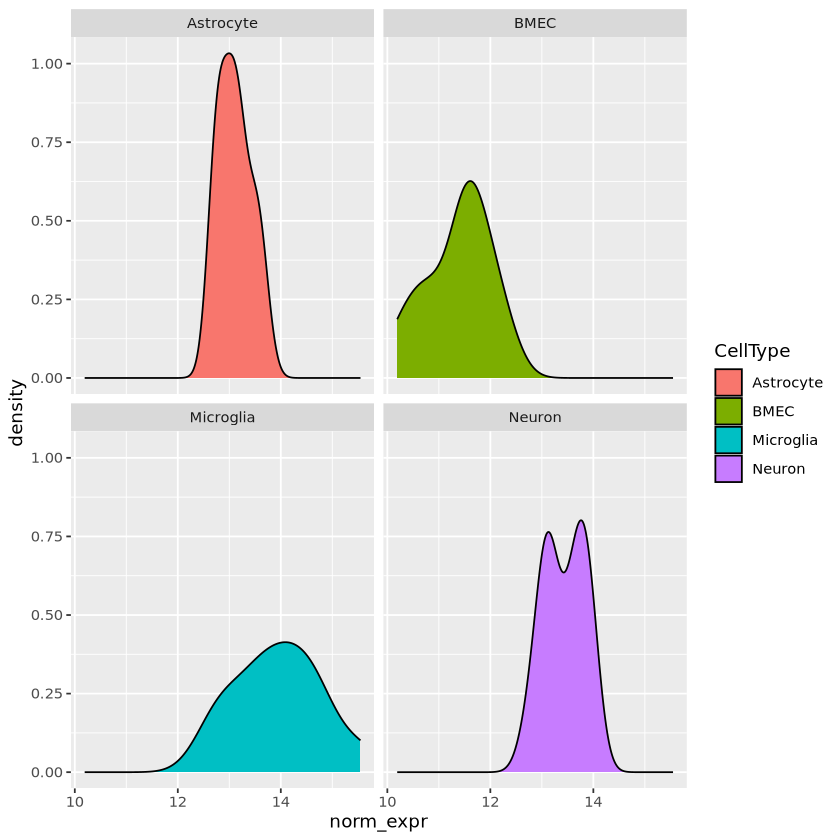

In [5]:
ggplot(expr_tcw)+geom_density(aes(x=norm_expr,fill=CellType))+facet_wrap('CellType')

#### APOE4 interaction analysis

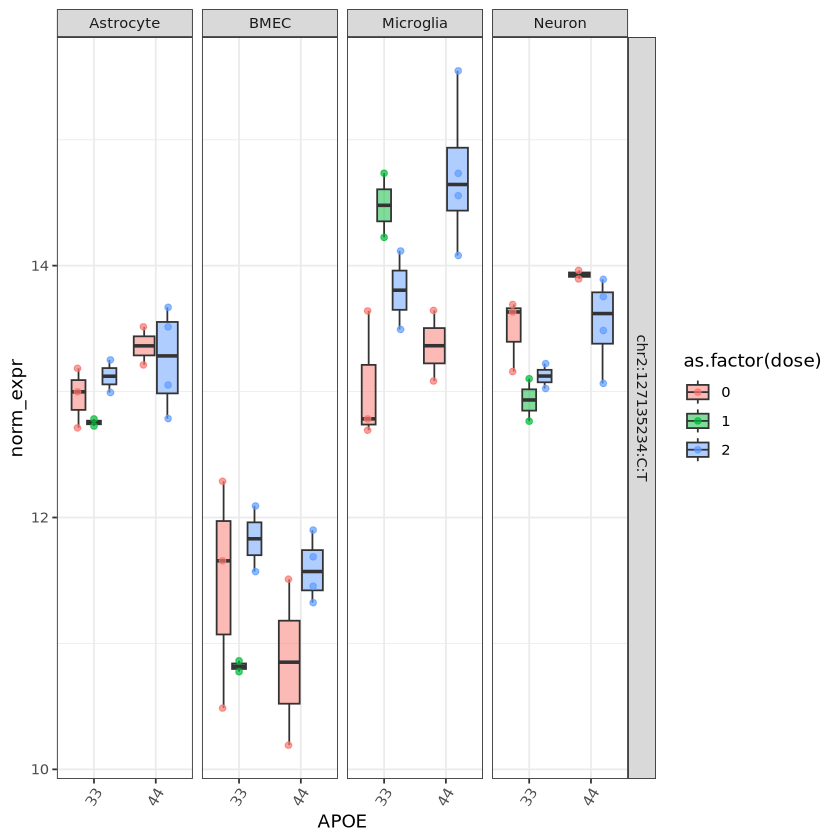

In [6]:
genoexpr_tcw <- merge(geno_tcw, expr_tcw, by = 'rand_ind_id', allow.cartesian = TRUE)
#vars_to_plot=variants_of_int #can be changed if too much Variants
#ge=ge[ID%in%vars_to_plot]
ggplot(genoexpr_tcw,aes(x=APOE,y=norm_expr))+
  geom_boxplot(aes(fill=as.factor(dose)),alpha=0.5)+
  geom_point(aes(col=as.factor(dose)),alpha=0.7,position = position_dodge(width = 0.8))+
  facet_grid(ID~CellType,scales = 'free_x',space = 'free_x')+
  theme_bw()+
  scale_x_discrete(guide = guide_axis(angle  =60))


In [7]:
# performing lm  
res_lm_tcw<-genoexpr_tcw[,data.table(summary(lm(norm_expr~dose*APOE+SEX))$coefficients,
                             keep.rownames ='cov'),by=.(ID,CellType)]
res_lm_tcw[cov=='dose:APOE44']

ID,CellType,cov,Estimate,Std. Error,t value,Pr(>|t|)
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
chr2:127135234:C:T,Astrocyte,dose:APOE44,-0.01783768,0.2183980,-0.08167512,0.9369115
chr2:127135234:C:T,BMEC,dose:APOE44,-0.01314383,0.4650475,-0.02826340,0.9781444
chr2:127135234:C:T,Microglia,dose:APOE44,0.30904394,0.4886382,0.63245958,0.5447348
chr2:127135234:C:T,Neuron,dose:APOE44,0.01604865,0.2340984,0.06855514,0.9470263


not enough power to detect interaction effect 
###  Young-Pearse ROSMAP iPSC data

In [8]:
variants_of_int

V1
<chr>
chr2:127135234:C:T


In [9]:
geno_ros=GetGenoROSMAP(variants_of_int%>%as.character,gname = gene_name)
head(geno_ros)

Extracting number of samples and rownames from ROSMAP_NIA_WGS.leftnorm.bcftools_qc.plink_qc.ENSG00000136717.fam...



Extracting number of variants and colnames from ROSMAP_NIA_WGS.leftnorm.bcftools_qc.plink_qc.ENSG00000136717.bim...



specimenID,ID,dose
<chr>,<fct>,<int>
MAP15387421,chr2:127135234:C:T,1
MAP26637867,chr2:127135234:C:T,0
MAP29629849,chr2:127135234:C:T,1
MAP33332646,chr2:127135234:C:T,2
MAP34726040,chr2:127135234:C:T,1
MAP46246604,chr2:127135234:C:T,1


In [10]:
expr_rosips<-GetExprROSiPSC(gname=gene_name)
head(expr_rosips)

extracting normalized expression data for BIN1 (ENSG00000136717)



iAstros



adding samples metadata



iNs



adding samples metadata



2 outlier found



BRID,gene_id,gene_name,norm_expr,individualID,projid.x,Study,msex,educ,race,⋯,samplingAgeUnits,visitNumber,assay,exclude,excludeReason,samplingDate,APOE,APOE4dose,is.outlier,CellType
<chr>,<chr>,<chr>,<dbl>,<chr>,<int>,<chr>,<int>,<int>,<int>,⋯,<lgl>,<lgl>,<chr>,<lgl>,<chr>,<lgl>,<chr>,<int>,<lgl>,<chr>
BR01,ENSG00000136717,BIN1,47.88445,R1408411,4127190,MAP,0,20,1,⋯,NA,NA,wholeGenomeSeq,FALSE,,NA,23,0,FALSE,iAstros
BR04,ENSG00000136717,BIN1,42.70511,R2880377,20207013,ROS,0,23,1,⋯,NA,NA,wholeGenomeSeq,FALSE,,NA,23,0,FALSE,iAstros
BR08,ENSG00000136717,BIN1,47.86407,R4323608,5498462,MAP,1,14,1,⋯,NA,NA,wholeGenomeSeq,FALSE,,NA,33,0,FALSE,iAstros
BR09,ENSG00000136717,BIN1,31.98115,R8125311,8637647,MAP,1,19,1,⋯,NA,NA,wholeGenomeSeq,FALSE,,NA,33,0,FALSE,iAstros
BR103,ENSG00000136717,BIN1,37.42861,R6600608,20124619,ROS,0,18,1,⋯,NA,NA,wholeGenomeSeq,FALSE,,NA,33,0,FALSE,iAstros
BR104,ENSG00000136717,BIN1,40.94340,R5518725,20447343,ROS,0,19,1,⋯,NA,NA,wholeGenomeSeq,FALSE,,NA,34,1,FALSE,iAstros


the function check if some outlier can be found based on the `boxplot.stats()$out`. These outliers should eventually be removed to ensure normal distribution

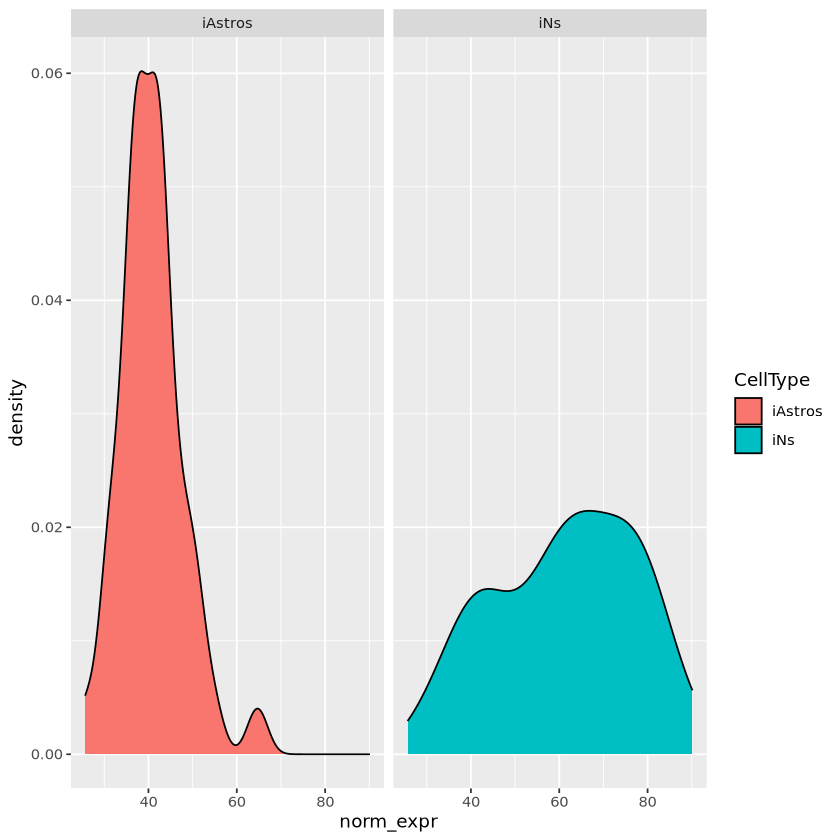

In [11]:
ggplot(expr_rosips)+geom_density(aes(x=norm_expr,fill=CellType))+facet_wrap('CellType')

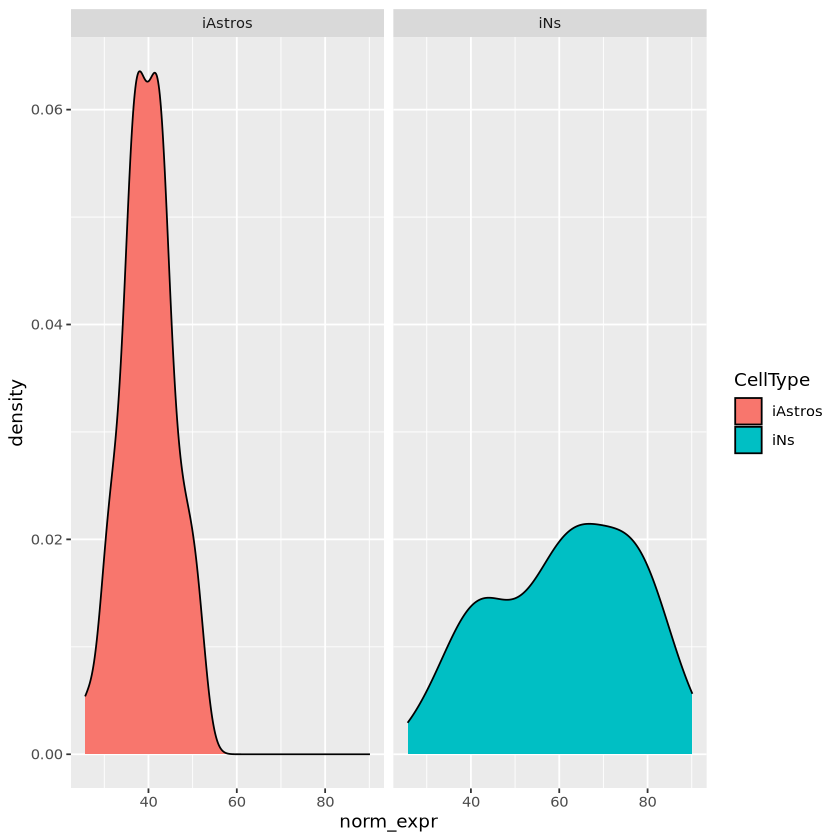

In [12]:
expr_rosips<-expr_rosips[!(is.outlier)]
ggplot(expr_rosips)+geom_density(aes(x=norm_expr,fill=CellType))+facet_wrap('CellType')

#### APOE4 interaction


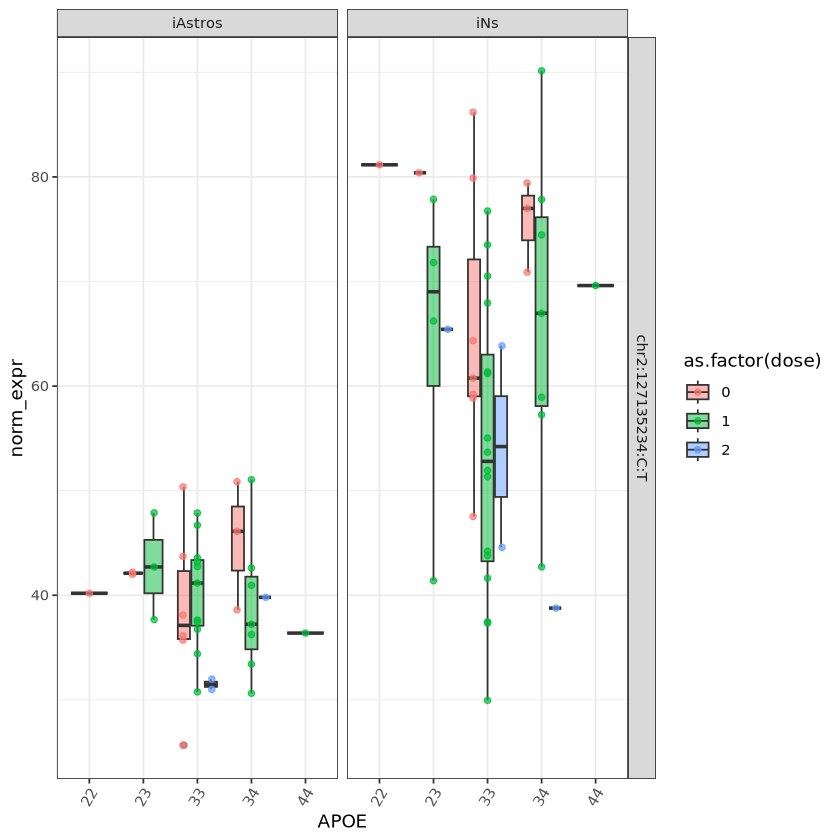

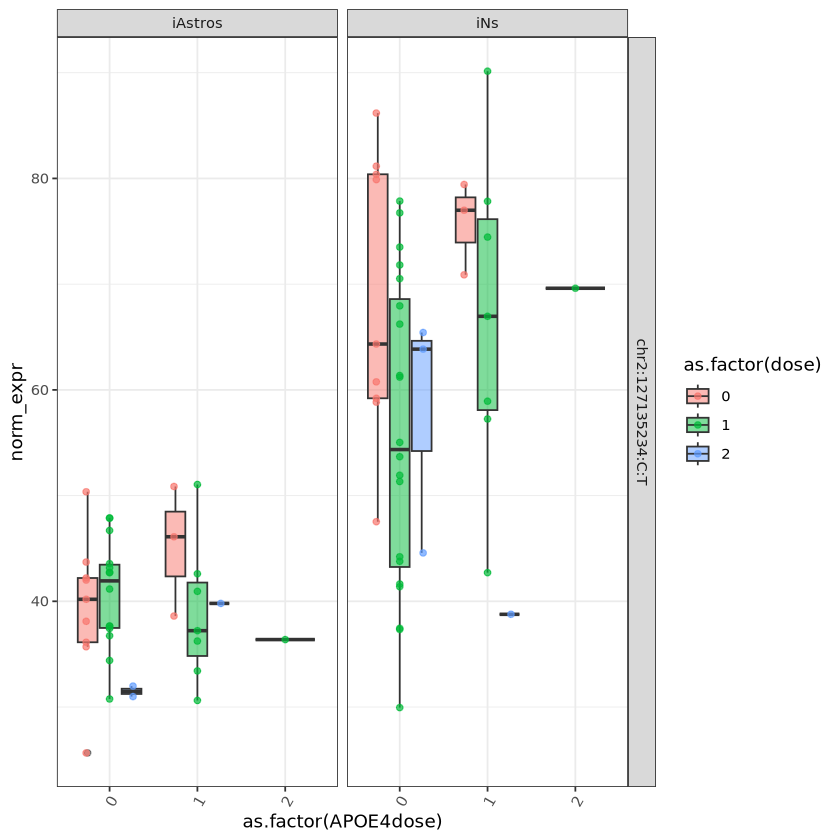

In [13]:
genoexpr_rosips<-merge(geno_ros,expr_rosips,by='specimenID')

#vars_to_plot=variants_of_int #can be changed if too much Variants
#ge=ge[ID%in%vars_to_plot]
ggplot(genoexpr_rosips,aes(x=APOE,y=norm_expr))+
  geom_boxplot(aes(fill=as.factor(dose)),alpha=0.5)+
  geom_point(aes(col=as.factor(dose)),alpha=0.7,position = position_dodge(width = 0.8))+
  facet_grid(ID~CellType,scales = 'free_x',space = 'free_x')+
  theme_bw()+
  scale_x_discrete(guide = guide_axis(angle  =60))

ggplot(genoexpr_rosips,aes(x=as.factor(APOE4dose),y=norm_expr))+
  geom_boxplot(aes(fill=as.factor(dose)),alpha=0.5)+
  geom_point(aes(col=as.factor(dose)),alpha=0.7,position = position_dodge(width = 0.8))+
  facet_grid(ID~CellType,scales = 'free_x',space = 'free_x')+
  theme_bw()+
  scale_x_discrete(guide = guide_axis(angle  =60))


In [14]:
# performin lm  
res_lm_rosips<-genoexpr_rosips[,data.table(summary(lm(norm_expr~dose*APOE4dose+msex))$coefficients,
                             keep.rownames ='cov'),by=.(ID,CellType)]
res_lm_rosips[cov=='dose:APOE4dose'] #ns


ID,CellType,cov,Estimate,Std. Error,t value,Pr(>|t|)
<fct>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
chr2:127135234:C:T,iAstros,dose:APOE4dose,-2.712785,3.792418,-0.7153181,0.4795995
chr2:127135234:C:T,iNs,dose:APOE4dose,-7.090880,8.461383,-0.8380286,0.4071214


## ROSMAP postmortem data
In this step, we query the APOE interaction QTL and report the finding.

In [15]:
library(tibble)
library(purrr)
library(data.table)

files <- Sys.glob("/data/analysis_result/marginal_significant_qtl/cis_association/ROSMAP/*/*/interaction/APOE/*significant_events*")

tb <- tibble(
  id   = paste("ROSMAP",
                          basename(dirname(dirname(dirname(files)))),           # *2
           basename(dirname(dirname(dirname(dirname(files))))),  # *1
           sep = "_"
         ),
  path = files,
  data = map(files, fread)                                      # list-column
)%>%unnest(data)


In [16]:
tb%>%colnames

[1] "id"                        "path"                     
 [3] "molecular_trait_object_id" "variant_id"               
 [5] "start_distance"            "end_distance"             
 [7] "af"                        "ma_samples"               
 [9] "ma_count"                  "pval_g"                   
[11] "b_g"                       "b_g_se"                   
[13] "pval_i"                    "b_i"                      
[15] "b_i_se"                    "pval_gi"                  
[17] "b_gi"                      "b_gi_se"                  
[19] "tests_emt"                 "pval_emt"                 
[21] "pval_adj_bh"               "p_bonferroni_min"         
[23] "fdr_bonferroni_min"        "q_bonferroni_min"

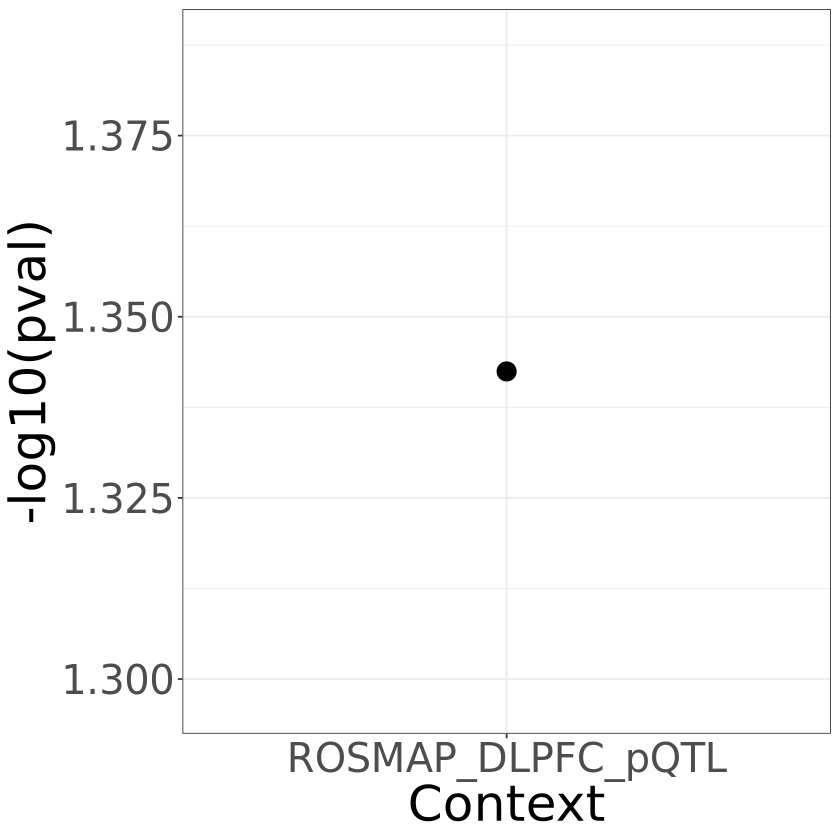

In [17]:
tb%>%filter(str_detect(molecular_trait_object_id,gene_id))%>%ggplot()+geom_point(aes(y = -log10(pval_adj_bh),x = id),size = 5)+xlab("Context")+ylab("-log10(pval)")+theme_bw()+theme(
    text = element_text(size = 30)
)